In [87]:
import pandas as pd
from sklearn.ensemble import IsolationForest


In [88]:
# Load the CSV file into a DataFrame
data = pd.read_csv('../data/data_uncorr.csv')

# Display the first few rows of the DataFrame
data.head()

,Unnamed: 0,name,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,...,round_B,round_C,round_D,round_E,round_F,round_G,international,european_or_international,time_to_first_funding,status_encoded
0,0,#waywire,News,1750000.0,acquired,USA,NY,New York City,New York,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,international,0.079452,0
1,11,1000 Markets,Marketplaces,500000.0,acquired,other,other,other,other,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,international,0.367123,0
2,12,1000memories,Curated Web,2535000.0,acquired,USA,CA,SF Bay Area,San Francisco,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,international,-0.495890,0
3,17,100Plus,Analytics,1250000.0,acquired,USA,CA,SF Bay Area,San Francisco,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,international,0.128767,0
4,20,10BestThings,Curated Web,50000.0,closed,USA,OH,Cleveland,Cleveland,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,international,0.000000,1


# One hot encoding

#### Binary Representation of Funding Rounds

In [89]:
data['had_round_A'] = [0 if x==0 else 1 for x in data['round_A']]
data['had_round_B'] = [0 if x==0 else 1 for x in data['round_B']]
data['had_round_C'] = [0 if x==0 else 1 for x in data['round_C']]
data['had_round_D'] = [0 if x==0 else 1 for x in data['round_D']]
data['had_round_E'] = [0 if x==0 else 1 for x in data['round_E']]
data['had_round_F'] = [0 if x==0 else 1 for x in data['round_F']]
data['had_round_G'] = [0 if x==0 else 1 for x in data['round_G']]
data['had_venture'] = [0 if x==0 else 1 for x in data['venture']]
data['had_seed'] = [0 if x==0 else 1 for x in data['seed']]
data['had_eq_crowdfunding'] = [0 if x==0 else 1 for x in data['equity_crowdfunding']]
data['had_pd_crowdfunding'] = [0 if x==0 else 1 for x in data['product_crowdfunding']]
data['had_angel'] = [0 if x==0 else 1 for x in data['angel']]
data['had_grant'] = [0 if x==0 else 1 for x in data['grant']]
data['had_pe'] = [0 if x==0 else 1 for x in data['private_equity']]
data['had_convert'] = [0 if x==0 else 1 for x in data['convertible_note']]

In [90]:
data.columns

Index(['Unnamed: 0', 'name', 'market', 'funding_total_usd', 'status',
       'country_code', 'state_code', 'region', 'city', 'funding_rounds',
       'founded_month', 'founded_year', 'seed', 'venture',
       'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity',
       'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D',
       'round_E', 'round_F', 'round_G', 'international',
       'european_or_international', 'time_to_first_funding', 'status_encoded',
       'had_round_A', 'had_round_B', 'had_round_C', 'had_round_D',
       'had_round_E', 'had_round_F', 'had_round_G', 'had_venture', 'had_seed',
       'had_eq_crowdfunding', 'had_pd_crowdfunding', 'had_angel', 'had_grant',
       'had_pe', 'had_convert'],
      dtype='object')

### Market Groups

In [91]:
# Define the mapping of markets to market groups
market_groups_mapping = {
    "Software & Tecnologie Digitali": [
        "Software", "Mobile", "Enterprise Software", "SaaS", "Cloud Computing",
        "Analytics", "AI & Machine Learning", "Data Security", "IT & Cybersecurity"
    ],
    "Salute, Benessere & Biotech": [
        "Health Care", "Health and Wellness", "Medical", "Pharmaceuticals",
        "Medical Devices", "Mobile Health", "Bioinformatics", "Healthcare Services"
    ],
    "E-Commerce & Retail": [
        "E-Commerce", "Online Shopping", "Mobile Commerce", "Retail",
        "Marketplaces", "Consumer Goods", "Fashion", "Mobile Advertising"
    ],
    "Media, Comunicazione & Intrattenimento": [
        "Social Media", "Social Network Media", "Social Media Marketing",
        "Entertainment", "Music", "Video Streaming", "Social Games", "Online Video Advertising"
    ],
    "Finanza & Business": [
        "Finance", "Financial Services", "Payments", "Venture Capital",
        "Crowdfunding", "Personal Finance", "Investment Management", "Business Analytics"
    ],
    "Educazione & Formazione": [
        "Education", "K-12 Education", "Career Management", "Training",
        "Language Learning", "Tutoring"
    ],
    "Tecnologie Innovative & Energia": [
        "Clean Technology", "Renewable Energies", "Solar", "Energy Efficiency",
        "Energy IT", "Smart Grid"
    ],
    "Automotive & Trasporti": [
        "Automotive", "Transportation", "Cars", "Fleet Management", "Taxis"
    ],
    "Real Estate & Immobili": [
        "Real Estate", "Property Management", "Commercial Real Estate", "Residential Solar"
    ],
    "Diversi & Altri Settori": [
        "Startups", "Consulting", "Nonprofits", "Sports", "Events",
        "Crowdsourcing", "Art", "Charity"
    ]
}

# Create a reverse mapping for easier lookup
reverse_mapping = {market: group for group, markets in market_groups_mapping.items() for market in markets}

# Add the "market groups" column to the dataframe
data["market groups"] = data["market"].map(reverse_mapping).fillna("Unknown")

In [92]:
data["market groups"].value_counts()

market groups
Unknown                                   2474
Software & Tecnologie Digitali             943
Media, Comunicazione & Intrattenimento     234
E-Commerce & Retail                        197
Salute, Benessere & Biotech                 99
Finanza & Business                          88
Diversi & Altri Settori                     79
Tecnologie Innovative & Energia             72
Educazione & Formazione                     45
Automotive & Trasporti                      23
Real Estate & Immobili                      15
Name: count, dtype: int64

In [93]:
# Perform one-hot encoding on the 'market groups' column
market_groups_encoded = pd.get_dummies(data['market groups'], prefix='market_group')

# Concatenate the encoded columns back to the original dataframe
data = pd.concat([data, market_groups_encoded], axis=1)

# Convert True/False to 0/1 for all boolean columns
market_groups_encoded = market_groups_encoded.astype(int)

# Aggiorna il dataframe originale
data.update(market_groups_encoded)

C:\Users\annal\AppData\Local\Temp\ipykernel_6700\1548527883.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 1 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.update(market_groups_encoded)
C:\Users\annal\AppData\Local\Temp\ipykernel_6700\1548527883.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.update(market_groups_encoded)
C:\Users\annal\AppData\Local\Temp\ipykernel_6700\1548527883.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.update(market_groups_encoded)
C:\Users\annal\AppD

In [94]:
data.columns

Index(['Unnamed: 0', 'name', 'market', 'funding_total_usd', 'status',
       'country_code', 'state_code', 'region', 'city', 'funding_rounds',
       'founded_month', 'founded_year', 'seed', 'venture',
       'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity',
       'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D',
       'round_E', 'round_F', 'round_G', 'international',
       'european_or_international', 'time_to_first_funding', 'status_encoded',
       'had_round_A', 'had_round_B', 'had_round_C', 'had_round_D',
       'had_round_E', 'had_round_F', 'had_round_G', 'had_venture', 'had_seed',
       'had_eq_crowdfunding', 'had_pd_crowdfunding', 'had_angel', 'had_grant',
       'had_pe', 'had_convert', 'market groups',
       'market_group_Automotive & Trasporti',
       'market_group_Diversi & Altri Settori',
       'market_group_E-Commerce & Retail',
       'market_group_Educazione & Formazione',
    

In [95]:
# Define numerical columns
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Initialize the Isolation Forest model
iso_forest = IsolationForest(random_state=42, contamination=0.05)

# Fit the model and predict anomalies
isolation_forest_pred = iso_forest.fit_predict(data[numerical_columns])

# Outliers are marked as -1
outliers_isolation_forest = data[numerical_columns][isolation_forest_pred == -1]

# Calculate the percentage of outliers
outlier_percentage = (len(outliers_isolation_forest) / len(data)) * 100
print(f"Percentage of outliers: {outlier_percentage:.2f}%")

Percentage of outliers: 5.01%


In [96]:
# Filter out the outliers
data_no_outliers = data[isolation_forest_pred != -1]

# Display the shape of the new dataset
print(f"Shape of dataset after removing outliers: {data_no_outliers.shape}")

Shape of dataset after removing outliers: (4055, 60)


## Decide which scaler use

In [97]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Create a copy before transforming, so the original data remains unchanged
data_no_outliers_standardized = data_no_outliers.copy()

# Standardize the numerical columns on the copied dataframe
data_no_outliers_standardized[numerical_columns] = scaler.fit_transform(data_no_outliers_standardized[numerical_columns])

# Display the first few rows of the standardized data
data_no_outliers_standardized.head()

,Unnamed: 0,name,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,...,market_group_Diversi & Altri Settori,market_group_E-Commerce & Retail,market_group_Educazione & Formazione,market_group_Finanza & Business,"market_group_Media, Comunicazione & Intrattenimento",market_group_Real Estate & Immobili,"market_group_Salute, Benessere & Biotech",market_group_Software & Tecnologie Digitali,market_group_Tecnologie Innovative & Energia,market_group_Unknown
0,-1.754151,#waywire,News,-0.081532,acquired,USA,NY,New York City,New York,-0.661103,...,-0.138204,-0.219259,-0.098545,-0.143664,-0.242377,-0.060933,-0.141865,-0.529138,-0.116175,0.835083
1,-1.753027,1000 Markets,Marketplaces,-0.095287,acquired,other,other,other,other,-0.661103,...,-0.138204,4.560820,-0.098545,-0.143664,-0.242377,-0.060933,-0.141865,-0.529138,-0.116175,-1.197486
2,-1.752925,1000memories,Curated Web,-0.072894,acquired,USA,CA,SF Bay Area,San Francisco,0.273942,...,-0.138204,-0.219259,-0.098545,-0.143664,-0.242377,-0.060933,-0.141865,-0.529138,-0.116175,0.835083
3,-1.752414,100Plus,Analytics,-0.087034,acquired,USA,CA,SF Bay Area,San Francisco,0.273942,...,-0.138204,-0.219259,-0.098545,-0.143664,-0.242377,-0.060933,-0.141865,1.889865,-0.116175,-1.197486
4,-1.752108,10BestThings,Curated Web,-0.100239,closed,USA,OH,Cleveland,Cleveland,-0.661103,...,-0.138204,-0.219259,-0.098545,-0.143664,-0.242377,-0.060933,-0.141865,-0.529138,-0.116175,0.835083


In [98]:
# Uncomment to Standardize between 0 and 1, but comment the StandardScaler cell

# from sklearn.preprocessing import MinMaxScaler

# # Initialize the MinMaxScaler
# min_max_scaler = MinMaxScaler()

# # Apply MinMaxScaler to the numerical columns
# data_no_outliers[numerical_columns] = min_max_scaler.fit_transform(data_no_outliers[numerical_columns])

# # Display the first few rows of the standardized data
# data_no_outliers.head()

## Normalize

In [99]:
from sklearn.preprocessing import normalize

# Normalize the numerical columns
data_no_outliers[numerical_columns] = normalize(data_no_outliers[numerical_columns])

# Display the first few rows of the normalized data
data_no_outliers.head()

# Normalize the numerical columns
data_no_outliers_standardized[numerical_columns] = normalize(data_no_outliers_standardized[numerical_columns])

# Display the first few rows of the normalized data
data_no_outliers_standardized.head()

C:\Users\annal\AppData\Local\Temp\ipykernel_6700\86974961.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_outliers[numerical_columns] = normalize(data_no_outliers[numerical_columns])


,Unnamed: 0,name,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,...,market_group_Diversi & Altri Settori,market_group_E-Commerce & Retail,market_group_Educazione & Formazione,market_group_Finanza & Business,"market_group_Media, Comunicazione & Intrattenimento",market_group_Real Estate & Immobili,"market_group_Salute, Benessere & Biotech",market_group_Software & Tecnologie Digitali,market_group_Tecnologie Innovative & Energia,market_group_Unknown
0,-0.406895,#waywire,News,-0.018912,acquired,USA,NY,New York City,New York,-0.153350,...,-0.032058,-0.050860,-0.022859,-0.033324,-0.056222,-0.014134,-0.032907,-0.122740,-0.026948,0.193707
1,-0.293467,1000 Markets,Marketplaces,-0.015952,acquired,other,other,other,other,-0.110672,...,-0.023136,0.763507,-0.016497,-0.024050,-0.040575,-0.010201,-0.023749,-0.088581,-0.019448,-0.200466
2,-0.453037,1000memories,Curated Web,-0.018839,acquired,USA,CA,SF Bay Area,San Francisco,0.070799,...,-0.035718,-0.056667,-0.025469,-0.037129,-0.062642,-0.015748,-0.036665,-0.136754,-0.030025,0.215824
3,-0.400363,100Plus,Analytics,-0.019884,acquired,USA,CA,SF Bay Area,San Francisco,0.062586,...,-0.031575,-0.050093,-0.022514,-0.032822,-0.055374,-0.013921,-0.032411,0.431766,-0.026542,-0.273582
4,-0.497358,10BestThings,Curated Web,-0.028454,closed,USA,OH,Cleveland,Cleveland,-0.187663,...,-0.039231,-0.062239,-0.027973,-0.040781,-0.068802,-0.017297,-0.040270,-0.150203,-0.032978,0.237049


## Logistic Regression

In [100]:
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
#%pip install matplotlib
#%pip install seaborn
#%pip install statsmodels
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sklearn.linear_model as skl_lm
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [110]:
X = data_no_outliers[numerical_columns.drop('Unnamed: 0')]
y = data_no_outliers['status']

# Map the 'status' column to numerical values (e.g., 'acquired' -> 1, 'closed' -> 0)
y_numeric = y.map({'acquired': 1, 'closed': 0})

# Drop rows with NaN values in y_numeric
valid_indices = y_numeric.dropna().index
X = X.loc[valid_indices]
y_numeric = y_numeric.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric)

# Remove columns with constant values
X_train = X_train.loc[:, (X_train != X_train.iloc[0]).any()]

# Add a constant to the features
X_train_w_intercept = sm.add_constant(X_train)




c:\Users\annal\OneDrive\Documenti\1Corso Data Analyst\0 Secondo Progetto\codice_progetto\startup-prediction\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Pred Prob    Pred Class  
-------------------------
0.94         1           
0.0          0           
0.81         1           
0.61         1           
0.68         1           
0.37         0           
0.84         1           
1.0          1           
0.0          0           
0.48         0           
0.51         1           
0.92         1           
0.91         1           
0.87         1           
0.91         1           
0.9          1           
0.0          0           
0.89         1           
0.9          1           
0.0          0           
1    485
0    326
Name: count, dtype: int64


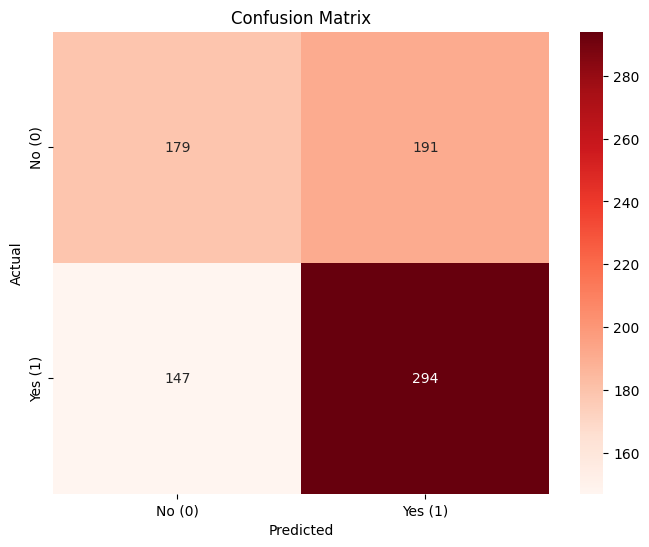

In [102]:
from sklearn.metrics import confusion_matrix

# Ensure X_test has the same columns as X_train_w_intercept (including the intercept)
X_test_aligned = X_test.reindex(columns=X_train.columns, fill_value=0)

# Add an intercept to the test dataset
X_test_w_intercept = sm.add_constant(X_test_aligned, has_constant='add')

# Ensure the columns in X_test_w_intercept match the model's coefficients
X_test_w_intercept = X_test_w_intercept.loc[:, est.params.index]

#Predict probabilities using the trained model
pred = est.predict(X_test_w_intercept).round(2)

#Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (pred > 0.5).astype(int)
#Print only the first 20 pairs with formatted alignment
print(f"{'Pred Prob':<12} {'Pred Class':<12}")  # Header
print("-" * 25)

for i in range(270, 290):
    print(f"{pred.values[i]:<12} {y_pred.values[i]:<12}")
print(y_pred.value_counts())

#Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

#Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [103]:
#Function to evaluate the performance of a classification model
def evaluate_classification_performance(y_test, y_pred):
    """
    Evaluate and print out standard classification metrics.
    """
    # Compute the confusion matrix
    conf_matrix = metrics.confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()

#Calculate specificity = TN / (TN + FP)
    specificity = tn / (tn + fp)

#Calculate other metrics using scikit-learn
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

#FPR = 1 - specificity
    fpr = 1 - specificity

#Print all metrics in a neat format
    print(f"Accuracy:    {accuracy:.2f}")
    print(f"Precision:   {precision:.2f}")
    print(f"Recall:      {recall:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"FPR:         {fpr:.2f}")
    print(f"F1 Score:    {f1:.2f}")

#Optionally return metrics in a dictionary if needed
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'f1_score': f1
    }


In [104]:
metrics_dict = evaluate_classification_performance(y_test, y_pred)

Accuracy:    0.58
Precision:   0.61
Recall:      0.67
Specificity: 0.48
FPR:         0.52
F1 Score:    0.63


In [105]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.48      0.51       370
           1       0.61      0.67      0.63       441

    accuracy                           0.58       811
   macro avg       0.58      0.58      0.57       811
weighted avg       0.58      0.58      0.58       811



In [106]:
# Convert y_train to numeric values (e.g., 0 and 1)
#y_train_numeric = y_train.map({'operating': 1, 'acquired': 0})

# Drop any rows with NaN values in y_train_numeric
#valid_indices = y_train_numeric.dropna().index
#y_train_numeric = y_train_numeric.loc[valid_indices]
#X_train_valid = X_train.loc[valid_indices]

# Add a constant to the features
#X_train_w_intercept = sm.add_constant(X_train_valid)

# Remove columns with constant values
#X_train_w_intercept = X_train_w_intercept.loc[:, (X_train_w_intercept != X_train_w_intercept.iloc[0]).any()]

# Fit the logistic regression model
#est = sm.Logit(y_train_numeric.to_numpy(), X_train_w_intercept).fit()
#est.summary().tables[1]

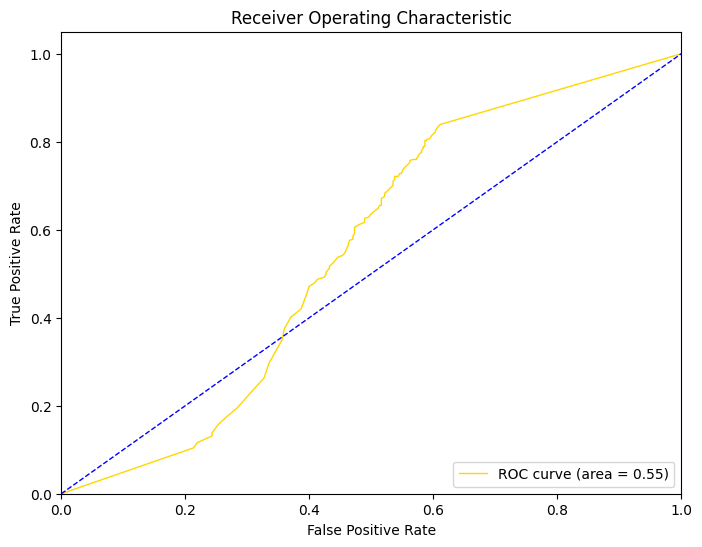

In [107]:
#Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, pred)

#Calculate AUC
roc_auc = roc_auc_score(y_test, pred)

#Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='gold', lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

In [108]:
#Calculate the Gini coefficient
gini = 2 * roc_auc - 1
print('Gini coefficient: %.2f' % gini)

Gini coefficient: 0.11


## Random Forest

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model
rf_model.fit(X_train_valid, y_train_numeric)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Map y_test to numeric values
y_test_mapped = y_test.map({'operating': 1, 'acquired': 0})

# Drop NaN values from y_test_mapped and reset its index
y_test_mapped = y_test_mapped.dropna().reset_index(drop=True)

# Align y_pred with the reset indices of y_test_mapped
y_pred_valid = y_pred[:len(y_test_mapped)]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_mapped, y_pred_valid))
print("\nClassification Report:\n", classification_report(y_test_mapped, y_pred_valid))

NameError: name 'X_train_valid' is not defined

## Alberi decisionali

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_valid, y_train_numeric)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Align y_pred_dt with the reset indices of y_test_mapped
y_pred_dt_valid = y_pred_dt[:len(y_test_mapped)]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_mapped, y_pred_dt_valid))
print("\nClassification Report:\n", classification_report(y_test_mapped, y_pred_dt_valid))

Accuracy: 0.8798163633382522

Classification Report:
               precision    recall  f1-score   support

         0.0       0.06      0.05      0.06       404
         1.0       0.93      0.94      0.94      5695

    accuracy                           0.88      6099
   macro avg       0.50      0.50      0.50      6099
weighted avg       0.88      0.88      0.88      6099



## Modello nearest neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_valid, y_train_numeric)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Align y_pred_knn with the reset indices of y_test_mapped
y_pred_knn_valid = y_pred_knn[:len(y_test_mapped)]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_mapped, y_pred_knn_valid))
print("\nClassification Report:\n", classification_report(y_test_mapped, y_pred_knn_valid))

Accuracy: 0.9263813739957371

Classification Report:
               precision    recall  f1-score   support

         0.0       0.04      0.00      0.01       404
         1.0       0.93      0.99      0.96      5695

    accuracy                           0.93      6099
   macro avg       0.49      0.50      0.49      6099
weighted avg       0.87      0.93      0.90      6099

